# Final Project: Solving an Educational Institution's Problem (Jaya Jaya Institut)

- Name: Fattan Naufan Islami
- Email: fattan124@gmail.com
- Dicoding ID: rainy1501

## Business Understanding

### Background
Jaya Jaya Institut is a higher education institution founded in 2000 that has produced many well-regarded graduates. However, the number of students who do not finish their studies (**dropout**) is still high. This hurts the institution's reputation, accreditation, and revenue, and it hurts the students themselves.

Jaya Jaya Institut wants to **detect students who are likely to drop out as early as possible** so they can receive targeted guidance.

### Business Problems
1. How high is the dropout rate at Jaya Jaya Institut?
2. Which factors (academic, financial, demographic, admission path) are most associated with dropout?
3. How can students at risk of dropping out be detected early and automatically?
4. How can the institution monitor student performance on an ongoing basis?

### Project Goals
1. Analyse the data to identify the main drivers of dropout.
2. Build a machine learning classification model that predicts whether a student will **Drop out** or **Graduate**.
3. Use the model to predict students who are still *Enrolled* (future data).
4. Provide an application prototype (Streamlit) so academic staff can use the model.
5. Provide a dashboard (Metabase) to monitor student performance.

## Preparation

### Importing the required libraries
Libraries used:
- `pandas` & `numpy` for data manipulation,
- `matplotlib` & `seaborn` for visualisation,
- `scikit-learn` for preprocessing, modeling, and evaluation,
- `joblib` to save the model,
- `sqlite3` to store the cleaned data in the database that Metabase reads,
- `utils.py` (local module) with the label mappings and the *feature engineering* function that the Streamlit app also uses, so data transformations in the notebook and the app are always identical.

In [1]:
import json
import sqlite3
import warnings

import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, classification_report, f1_score,
                             precision_recall_curve, precision_score, recall_score,
                             roc_auc_score, roc_curve)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold, cross_val_predict,
                                     cross_validate, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

from utils import (COURSE, CATEGORICAL_FEATURES, ENGINEERED_FEATURES, MODEL_FEATURES,
                   NUMERIC_FEATURES, add_engineered_features, add_labels)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
RANDOM_STATE = 42
print("scikit-learn", sklearn.__version__, "| pandas", pd.__version__)

scikit-learn 1.9.1 | pandas 3.0.6


The visual style is consistent throughout the notebook:
- **Fixed status colours**: Dropout = orange, Enrolled = aqua green, Graduate = blue (the palette has been checked to be colour-blind safe).
- On *dropout rate* charts, **orange** bars mark categories whose dropout rate is **above the institution average**, while grey bars are below average. The dashed line shows the overall average.
- Percentage axes always start at 0 and every bar is labelled with its value and the number of students (n), so comparisons are honest and not misleading.

In [2]:
STATUS_ORDER = ["Dropout", "Enrolled", "Graduate"]
STATUS_COLORS = {"Dropout": "#eb6834", "Enrolled": "#1baf7a", "Graduate": "#2a78d6"}
HIGHLIGHT, NEUTRAL = "#eb6834", "#c3c2b7"
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e1e0d9"

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": MUTED,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "font.size": 10,
    "legend.frameon": False,
})

### Loading the data
The dataset is Dicoding's [*Students' Performance*](https://github.com/dicodingacademy/dicoding_dataset/tree/main/students_performance), with 4,424 students from a range of study programs. A copy is stored in `data/data.csv` (semicolon-separated) and is identical to the original file in the Dicoding repository.

In [3]:
DATASET_URL = "https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/main/students_performance/data.csv"
df = pd.read_csv("data/data.csv", sep=";")  # local copy of DATASET_URL
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

### Data structure and quality

In [4]:
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.info()

Rows: 4,424 | Columns: 37
<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         44

In [5]:
print("Total missing values:", df.isna().sum().sum())
print("Total duplicate rows:", df.duplicated().sum())

Total missing values: 0
Total duplicate rows: 0


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital_status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application_mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application_order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime_evening_attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous_qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous_qualification_grade,4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mothers_qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Fathers_qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


**Insight:**
- The dataset has **4,424 rows and 37 columns** (36 features + the `Status` target).
- There are **no missing values and no duplicate rows**, so no imputation or row removal is needed.
- Every feature is numeric, but many of them are actually **categorical values encoded as numbers** (e.g. `Course`, `Application_mode`, `Marital_status`). To make them easier to analyse, the codes are mapped to labels with `add_labels()` from `utils.py`.
- Values fall within reasonable ranges according to the documentation (admission grade 95–190 on a 0–200 scale, semester grades 0–20, age 17–70). Extreme values such as an age of 70 are real cases (mature students), not input errors, so they are kept.

Feature groups in the dataset:

| Group | Example features |
|---|---|
| Demographic | `Marital_status`, `Gender`, `Age_at_enrollment`, `Nacionality`, `International`, `Displaced` |
| Admission & academic background | `Application_mode`, `Application_order`, `Course`, `Previous_qualification(_grade)`, `Admission_grade` |
| Family socio-economic | `Mothers/Fathers_qualification`, `Mothers/Fathers_occupation` |
| Financial | `Debtor`, `Tuition_fees_up_to_date`, `Scholarship_holder` |
| Academic performance, semesters 1 & 2 | `Curricular_units_*_sem_(credited/enrolled/evaluations/approved/grade/without_evaluations)` |
| Macroeconomic | `Unemployment_rate`, `Inflation_rate`, `GDP` |

In [7]:
df_eda = add_engineered_features(add_labels(df))
df_eda["Status"] = pd.Categorical(df_eda["Status"], categories=STATUS_ORDER, ordered=True)
df_eda["Is_dropout"] = (df_eda["Status"] == "Dropout").astype(int)
df_eda["Age_group"] = pd.cut(df_eda["Age_at_enrollment"], bins=[0, 20, 24, 29, 39, 100],
                             labels=["<=20", "21-24", "25-29", "30-39", "40+"])
OVERALL_DROPOUT = df_eda["Is_dropout"].mean()
df_eda[["Course", "Course_label", "Application_mode_label", "Gender_label", "Status"]].head()

,Course,Course_label,Application_mode_label,Gender_label,Status
0,171,Animation and Multimedia Design,2nd phase - general contingent,Male,Dropout
1,9254,Tourism,International student (bachelor),Male,Graduate
2,9070,Communication Design,1st phase - general contingent,Male,Dropout
3,9773,Journalism and Communication,2nd phase - general contingent,Female,Graduate
4,8014,Social Service (evening attendance),Over 23 years old,Female,Graduate


### Exploratory Data Analysis (EDA)

The EDA uses **all 4,424 students** (including *Enrolled*) to give a complete picture of the institution. The data is split for modeling in the Data Preparation stage.

#### 1. Student status distribution

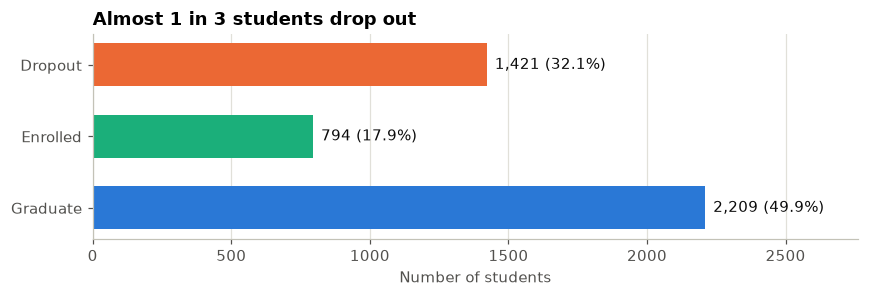

In [8]:
status = df_eda["Status"].value_counts().reindex(STATUS_ORDER)
fig, ax = plt.subplots(figsize=(8, 2.8))
bars = ax.barh(status.index[::-1], status.values[::-1],
               color=[STATUS_COLORS[s] for s in status.index[::-1]], height=0.6)
for b, v in zip(bars, status.values[::-1]):
    ax.text(b.get_width() + 30, b.get_y() + b.get_height() / 2,
            f"{v:,} ({v / len(df_eda):.1%})", va="center", color=INK)
ax.set_xlim(0, status.max() * 1.25)
ax.set_xlabel("Number of students")
ax.grid(axis="y", visible=False)
ax.set_title("Almost 1 in 3 students drop out")
plt.tight_layout()
plt.show()

**Insight:**
- **32.1% of students (1,421) dropped out**, a very high figure and the core of Jaya Jaya Institut's problem.
- 49.9% graduated (*Graduate*) and 17.9% were still enrolled (*Enrolled*) after the normal study period. The *Enrolled* status is **not final**: these students may still graduate or drop out later.
- Modeling therefore only uses students whose final outcome is known (*Dropout* and *Graduate*), while *Enrolled* students become the data to predict.

#### Dropout-rate plotting helper

In [9]:
def dropout_rate_table(col, min_n=0, sort=True):
    t = df_eda.groupby(col, observed=True)["Is_dropout"].agg(rate="mean", n="size")
    t = t[t["n"] >= min_n]
    return t.sort_values("rate") if sort else t


def plot_dropout_rate(ax, col, title, min_n=0, sort=True):
    """Horizontal bar chart of the dropout rate per category.

    sort=True  -> nominal categories are ordered from the lowest to the highest dropout rate.
    sort=False -> ordinal categories (age, number of courses) keep their natural top-to-bottom order.
    """
    t = dropout_rate_table(col, min_n, sort)
    colors = [HIGHLIGHT if r > OVERALL_DROPOUT else NEUTRAL for r in t["rate"]]
    bars = ax.barh(t.index.astype(str), t["rate"] * 100, color=colors, height=0.6)
    for b, (r, n) in zip(bars, t[["rate", "n"]].values):
        ax.text(b.get_width() + 1.5, b.get_y() + b.get_height() / 2,
                f"{r:.0%}  (n={int(n):,})", va="center", fontsize=9, color=MUTED,
                bbox={"facecolor": "white", "edgecolor": "none", "pad": 1})
    ax.axvline(OVERALL_DROPOUT * 100, color=INK, ls="--", lw=1, zorder=1)
    ax.set_xlim(0, 105)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_xlabel(f"Dropout rate  (dashed line = average {OVERALL_DROPOUT:.0%})")
    ax.grid(axis="y", visible=False)
    ax.set_title(title)
    if not sort:
        ax.invert_yaxis()
    return t

#### 2. Academic performance in semesters 1 & 2

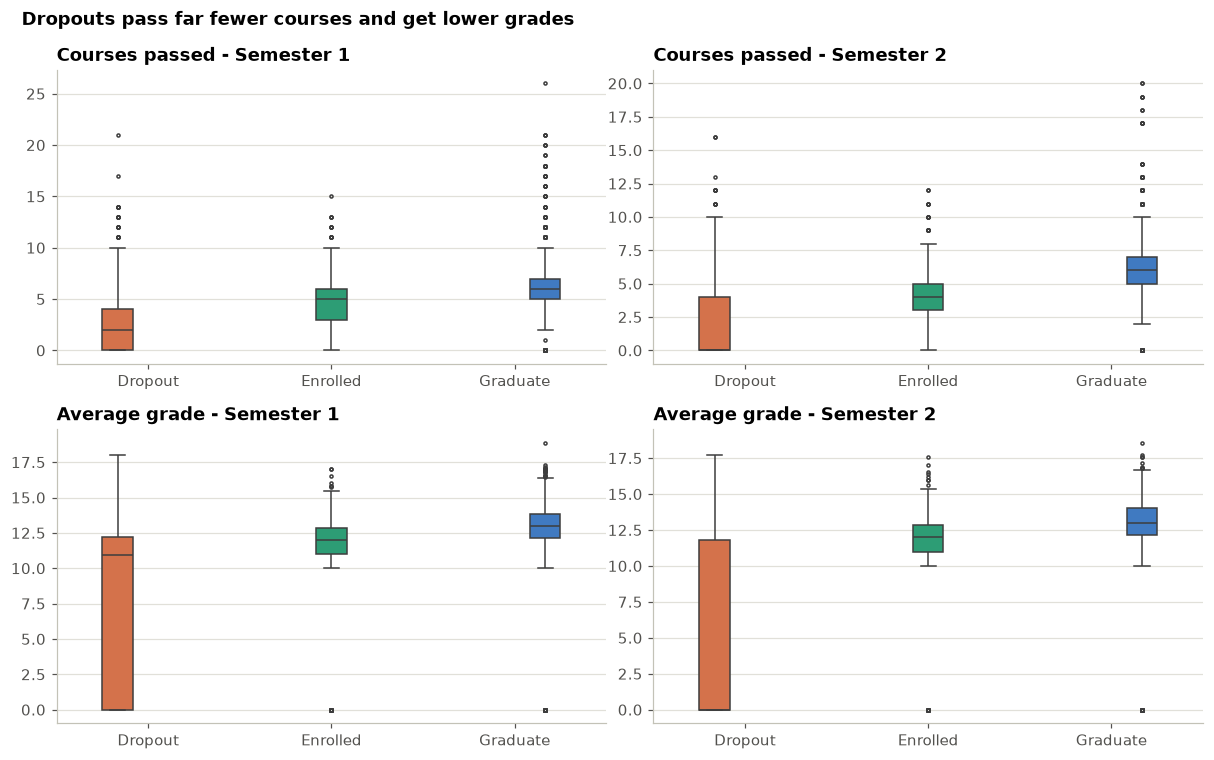

Status,Dropout,Enrolled,Graduate
Curricular_units_1st_sem_approved,2.00,5.00,6.0
Curricular_units_2nd_sem_approved,0.00,4.00,6.0
Curricular_units_1st_sem_grade,10.93,12.00,13.0
Curricular_units_2nd_sem_grade,0.00,12.00,13.0
Approval_rate_1st_sem,0.33,0.80,1.0
Approval_rate_2nd_sem,0.00,0.69,1.0


In [10]:
academic_cols = {
    "Curricular_units_1st_sem_approved": "Courses passed - Semester 1",
    "Curricular_units_2nd_sem_approved": "Courses passed - Semester 2",
    "Curricular_units_1st_sem_grade": "Average grade - Semester 1",
    "Curricular_units_2nd_sem_grade": "Average grade - Semester 2",
}
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, (col, label) in zip(axes.ravel(), academic_cols.items()):
    sns.boxplot(data=df_eda, x="Status", y=col, hue="Status", order=STATUS_ORDER,
                palette=STATUS_COLORS, width=0.5, fliersize=2, linewidth=1, legend=False, ax=ax)
    ax.set_title(label)
    ax.set_xlabel("")
    ax.set_ylabel("")
fig.suptitle("Dropouts pass far fewer courses and get lower grades",
             x=0.01, ha="left", fontweight="bold")
plt.tight_layout()
plt.show()

df_eda.groupby("Status", observed=True)[list(academic_cols) + ENGINEERED_FEATURES].median().round(2).T

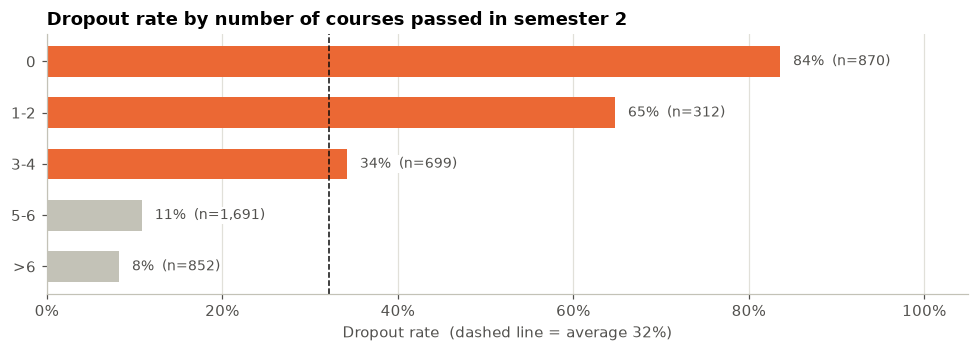

In [11]:
df_eda["Approved_2nd_group"] = pd.cut(df_eda["Curricular_units_2nd_sem_approved"],
                                      bins=[-1, 0, 2, 4, 6, 100],
                                      labels=["0", "1-2", "3-4", "5-6", ">6"])
fig, ax = plt.subplots(figsize=(9, 3.3))
t = plot_dropout_rate(ax, "Approved_2nd_group",
                      "Dropout rate by number of courses passed in semester 2", sort=False)
plt.tight_layout()
plt.show()

**Insight:**
- Academic performance is **the strongest differentiator**. The median number of courses passed by dropouts is only **2 in semester 1 and 0 in semester 2**, compared with 6 for students who graduate.
- The median course pass rate (*approval rate*) of dropouts is only 33% in semester 1 and 0% in semester 2, versus 100% for graduates.
- **870 students passed no courses at all in semester 2**, and **84%** of them dropped out. The more courses a student passes, the more sharply the dropout rate falls.
- In other words, **grades and course passes in semesters 1–2 are the best early warning signals**. Students with a low approval rate from semester 1 should receive academic intervention immediately.
- *Enrolled* students sit in the middle: they perform worse than graduates but far better than dropouts.

#### 3. Financial factors

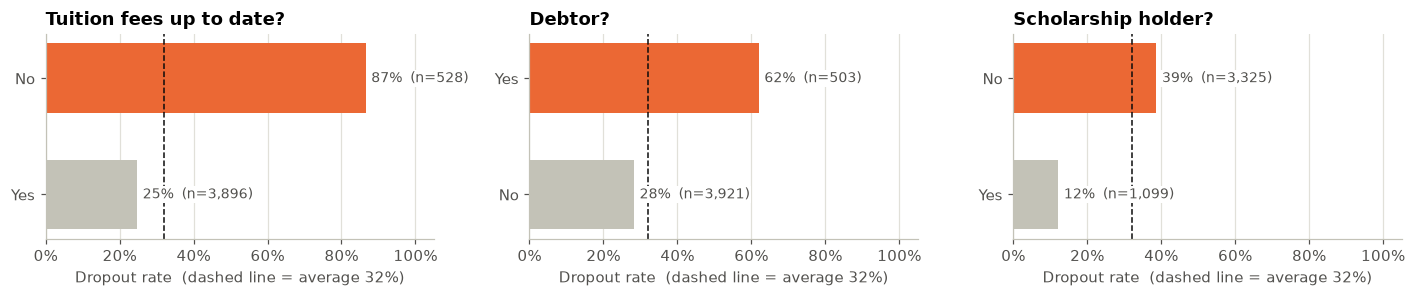

Students with overdue tuition AND debt: 246, dropout rate 87.4%


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 2.8), sharex=True)
plot_dropout_rate(axes[0], "Tuition_fees_up_to_date_label", "Tuition fees up to date?")
plot_dropout_rate(axes[1], "Debtor_label", "Debtor?")
plot_dropout_rate(axes[2], "Scholarship_holder_label", "Scholarship holder?")
plt.tight_layout()
plt.show()

both = df_eda[(df_eda["Tuition_fees_up_to_date"] == 0) & (df_eda["Debtor"] == 1)]
print(f"Students with overdue tuition AND debt: {len(both)}, "
      f"dropout rate {both['Is_dropout'].mean():.1%}")

**Insight:**
- **Overdue tuition is the strongest non-academic factor.** Students whose tuition is not up to date have a dropout rate of **87%**, far above those who are paid up (25%).
- Debtors have a dropout rate of **62%**, more than twice that of students without debt (28%).
- When both conditions occur together (overdue tuition and debt), the dropout rate reaches about **87%**.
- Conversely, **scholarship holders drop out far less often (12%)** than non-holders (39%). Financial support is clearly linked to students completing their studies.

#### 4. Demographic factors

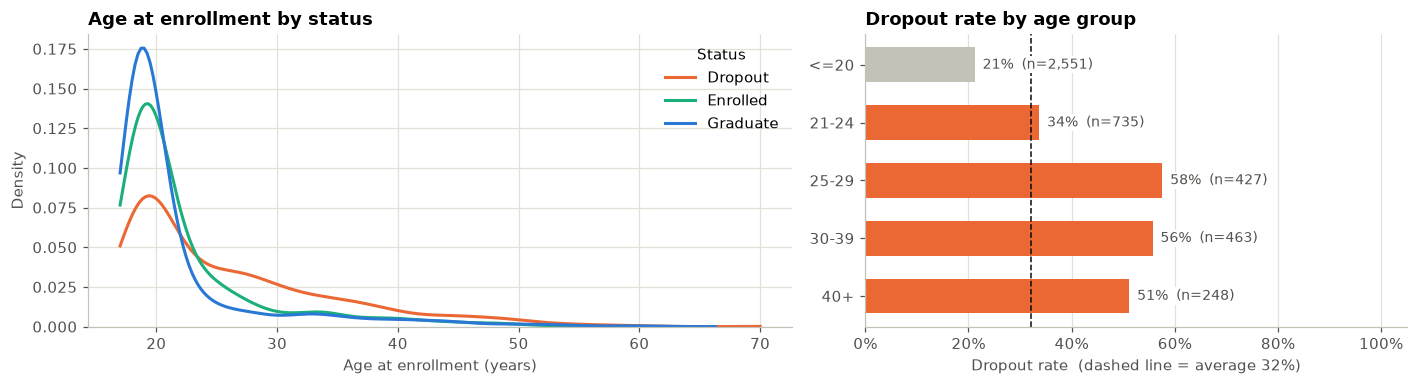

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6), gridspec_kw={"width_ratios": [1.3, 1]})
for s in STATUS_ORDER:
    sns.kdeplot(data=df_eda[df_eda["Status"] == s], x="Age_at_enrollment", ax=axes[0],
                color=STATUS_COLORS[s], lw=2, label=s, common_norm=False, clip=(17, 70))
axes[0].set_title("Age at enrollment by status")
axes[0].set_xlabel("Age at enrollment (years)")
axes[0].set_ylabel("Density")
axes[0].legend(title="Status")
plot_dropout_rate(axes[1], "Age_group", "Dropout rate by age group", sort=False)
plt.tight_layout()
plt.show()

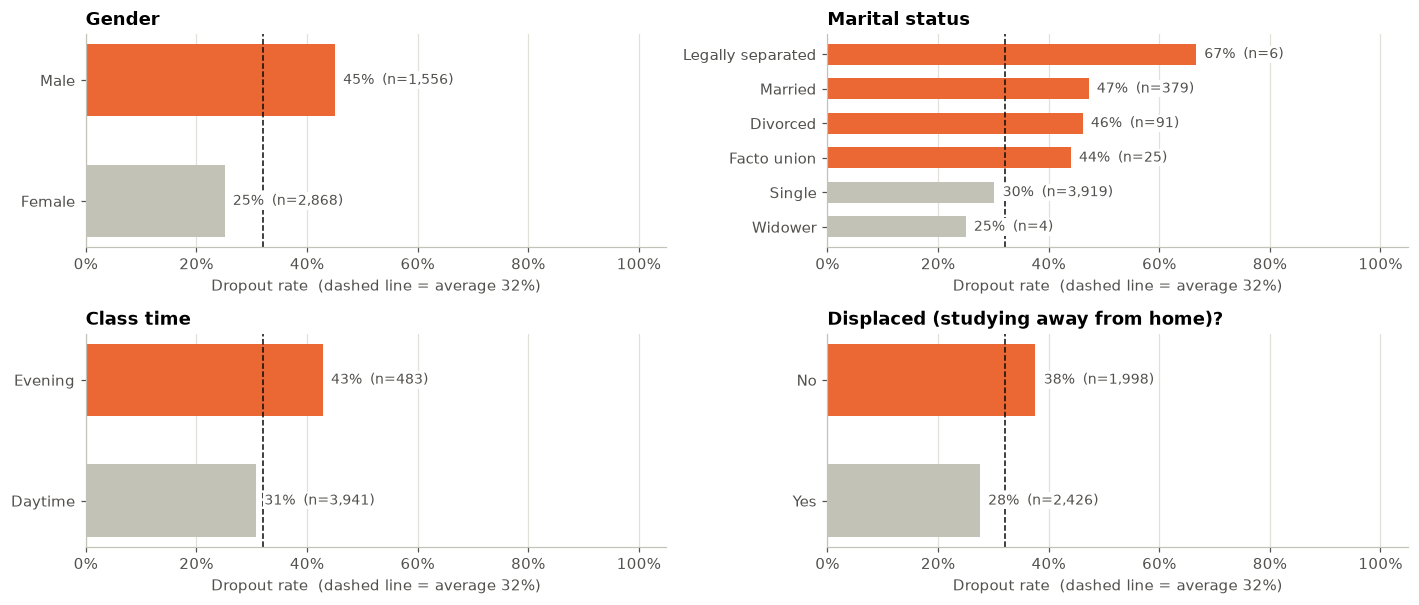

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(13, 5.6))
plot_dropout_rate(axes[0, 0], "Gender_label", "Gender")
plot_dropout_rate(axes[0, 1], "Marital_status_label", "Marital status")
plot_dropout_rate(axes[1, 0], "Attendance_label", "Class time")
plot_dropout_rate(axes[1, 1], "Displaced_label", "Displaced (studying away from home)?")
plt.tight_layout()
plt.show()

**Insight:**
- **Age at enrollment** matters a lot. Students aged ≤20 have a dropout rate of 21%, while students aged **25 and over exceed 50%**. Mature students tend to have other commitments (work, family) that compete with their studies.
- **Male** students have a dropout rate of **45%**, far above female students (25%).
- **Married/divorced** students and those in **evening classes** are also at higher risk, consistent with the profile of mature working students.
- Interestingly, displaced students (*displaced*) drop out slightly less often (28% vs 38%), most likely because they are usually younger (fresh high-school graduates).
- Categories with a very small n (e.g. *Legally separated*, n=6) should be read with caution.

#### 5. Study program and admission path

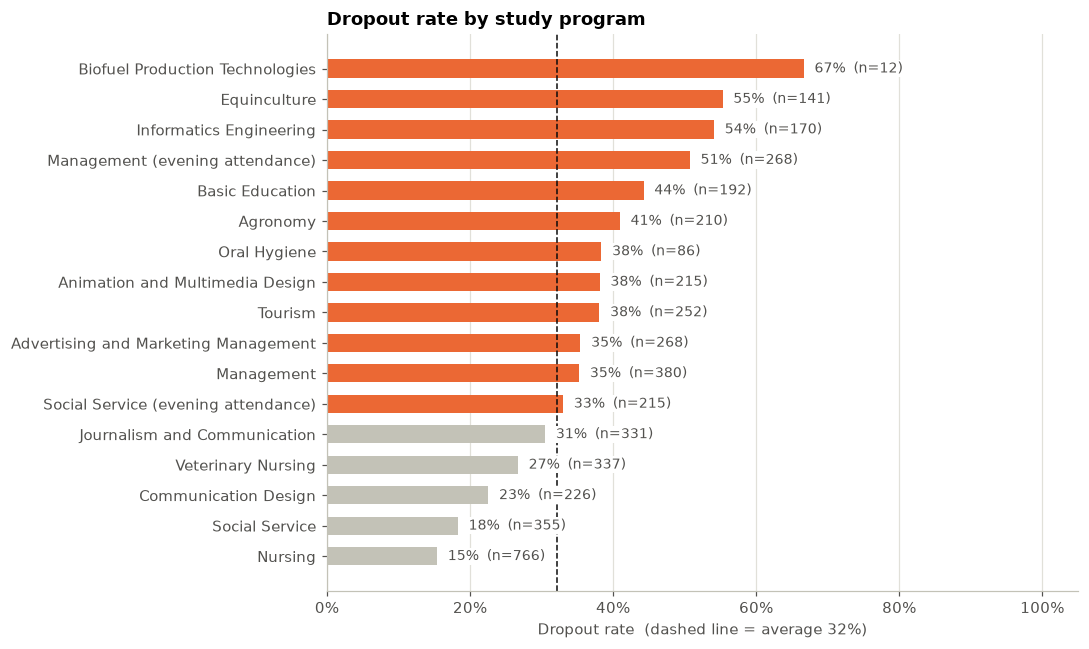

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_dropout_rate(ax, "Course_label", "Dropout rate by study program")
plt.tight_layout()
plt.show()

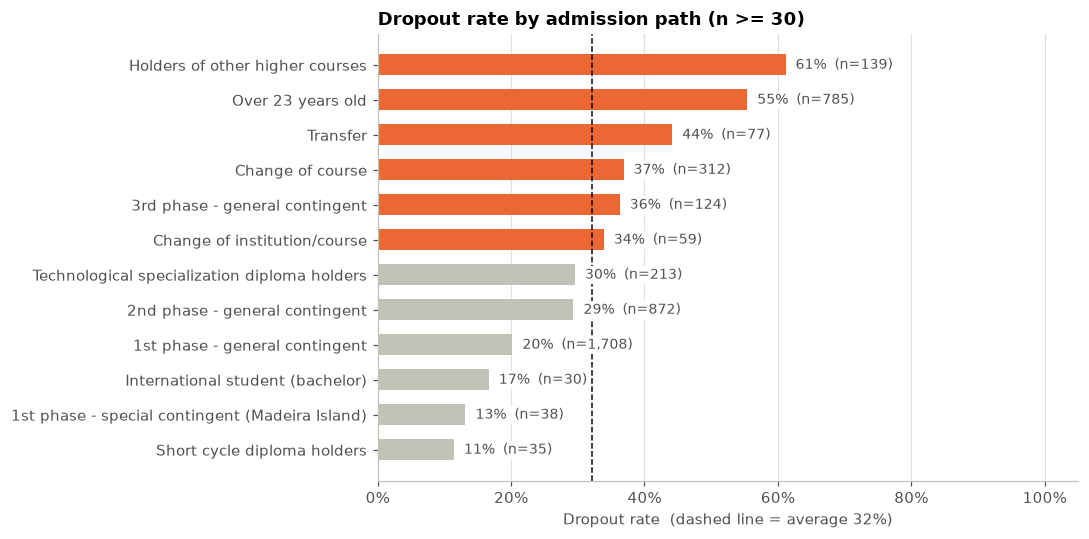

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_dropout_rate(ax, "Application_mode_label", "Dropout rate by admission path (n >= 30)", min_n=30)
plt.tight_layout()
plt.show()

**Insight:**
- The dropout rate varies widely between study programs. **Nursing (15%) and Social Service (18%)** are the lowest, while **Equinculture (55%), Informatics Engineering (54%), and Management (evening) (51%)** are the highest. *Biofuel Production Technologies* (67%) has only 12 students, so it is not representative.
- By admission path, the **"Over 23 years old" (55%, n=785)** and **"Holders of other higher courses" (61%)** paths carry the most risk. This reinforces the age finding: paths for mature students are a vulnerable group.
- The regular **"1st phase - general contingent"** path (the largest, n=1,708) has the lowest dropout rate among the large paths (20%).

#### 6. Parents' background and macroeconomic conditions

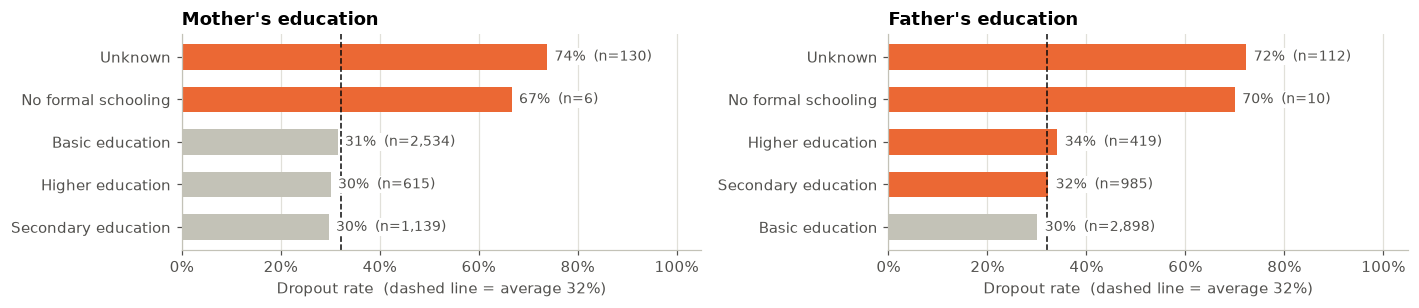

Dropout rate range across unemployment-rate values: 24% - 38% | correlation with dropout: 0.013


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 2.9))
plot_dropout_rate(axes[0], "Mothers_education_label", "Mother's education")
plot_dropout_rate(axes[1], "Fathers_education_label", "Father's education")
plt.tight_layout()
plt.show()

macro = df_eda.groupby("Unemployment_rate")["Is_dropout"].mean()
print("Dropout rate range across unemployment-rate values:",
      f"{macro.min():.0%} - {macro.max():.0%}",
      f"| correlation with dropout: {df_eda['Unemployment_rate'].corr(df_eda['Is_dropout']):.3f}")

**Insight:**
- Apart from the *Unknown* category (parents' education not recorded, 74% dropout), **parents' education level barely changes the dropout rate** (about 30% at every level). The high dropout rate in the *Unknown* category most likely reflects incomplete enrollment records rather than education itself.
- The macroeconomic indicators (*unemployment rate*, inflation, GDP) have only 10 unique values (tied to the enrollment year) and correlate very weakly with dropout. They are also **not something the institution can act on**.

#### 7. Correlation of numeric features with dropout
The correlation is computed between each numeric/binary feature and the dropout indicator (1 = Dropout, 0 = otherwise). Nominal categorical features encoded as numbers (e.g. `Course`) are excluded because correlations on nominal codes are meaningless.

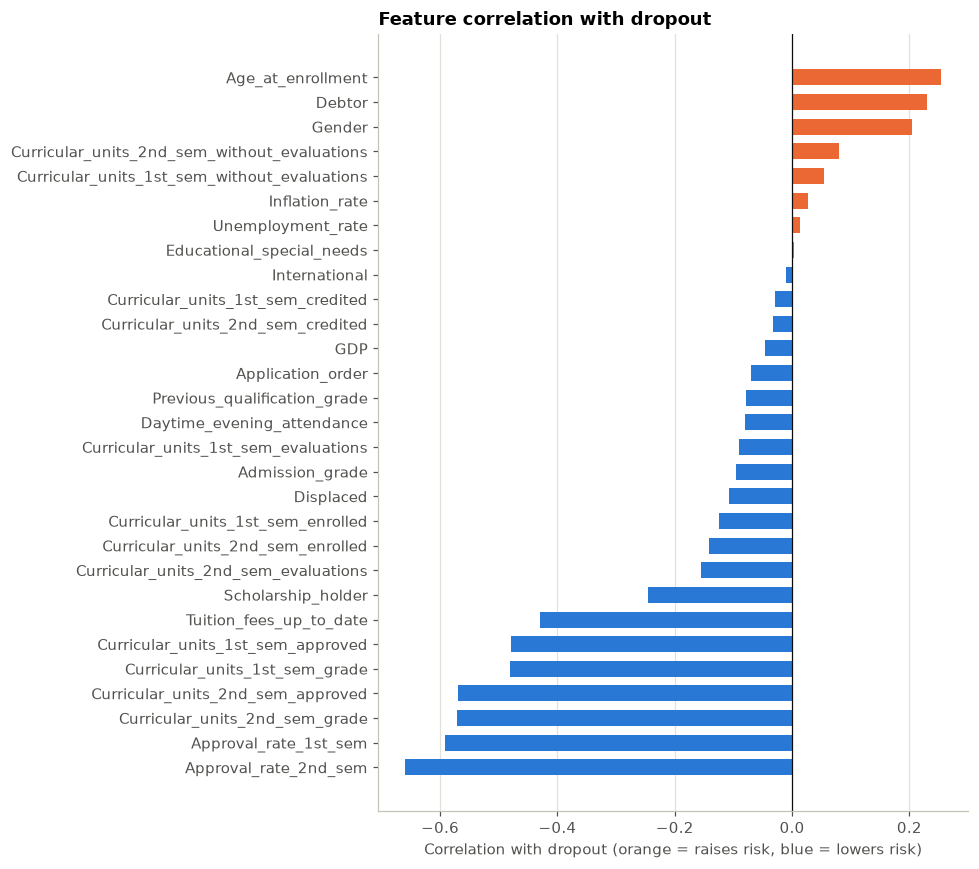

In [18]:
nominal_codes = ["Marital_status", "Application_mode", "Course", "Previous_qualification", "Nacionality",
                 "Mothers_qualification", "Fathers_qualification", "Mothers_occupation", "Fathers_occupation"]
num_cols = [c for c in df.columns if c not in nominal_codes + ["Status"]] + ENGINEERED_FEATURES
corr = df_eda[num_cols].corrwith(df_eda["Is_dropout"]).sort_values()

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(corr.index, corr.values, color=[HIGHLIGHT if v > 0 else "#2a78d6" for v in corr.values], height=0.65)
ax.axvline(0, color=INK, lw=0.8)
ax.set_xlabel("Correlation with dropout (orange = raises risk, blue = lowers risk)")
ax.grid(axis="y", visible=False)
ax.set_title("Feature correlation with dropout")
plt.tight_layout()
plt.show()

**Insight:**
- Strongest negative correlations (protective factors): **approval rate and number of courses passed in semesters 2 & 1, average semester grades, tuition paid up, and scholarship status**.
- Strongest positive correlations (risk factors): **age at enrollment, debtor status, and male gender**.
- Macroeconomic features, special educational needs, and international status have correlations close to zero.

**EDA summary - main drivers of dropout:**
1. **Academic**: few courses passed and low grades in semesters 1–2 (strongest factor).
2. **Financial**: overdue tuition, debt, no scholarship.
3. **Demographic**: enrollment age ≥25, male, married, evening classes.
4. **Admission path & study program**: the *Over 23 years old* path, and programs such as Equinculture, Informatics Engineering, and Management (evening).

## Data Preparation / Preprocessing

### 1. Separating the modeling data from the prediction data
The goal of the system is to predict whether a student will **Drop out** or **Graduate**. Therefore:
- The **modeling data** only contains students whose final outcome is already known: **Dropout** and **Graduate**.
- **Enrolled** students are still studying and their final outcome is **unknown**. Merging them into either class would make the target ambiguous, so they are **set aside as future prediction data** and are not used for training or evaluation.

The target is binary: `1` = **Dropout**, `0` = **Graduate**.

In [19]:
model_df = df[df["Status"].isin(["Dropout", "Graduate"])].copy()
enrolled_df = df[df["Status"] == "Enrolled"].copy()

y = (model_df["Status"] == "Dropout").astype(int)
print(f"Modeling data (Dropout + Graduate): {len(model_df):,} students")
print(f"Future prediction data (Enrolled):  {len(enrolled_df):,} students")
y.value_counts().rename(index={1: "Dropout (1)", 0: "Graduate (0)"}).to_frame("count").assign(
    share=lambda t: (t["count"] / t["count"].sum()).round(3))

Modeling data (Dropout + Graduate): 3,630 students
Future prediction data (Enrolled):  794 students


,count,share
Status,,
Graduate (0),2209,0.609
Dropout (1),1421,0.391


**Insight:** The modeling data has **3,630 students**, 39% Dropout and 61% Graduate. The classes are fairly imbalanced, so the model is evaluated with **F1-score, recall, and ROC-AUC**, not accuracy alone. The **794 Enrolled students** are kept aside to be predicted once the model is built.

### 2. Feature selection
Based on the EDA, **20 features** were selected that are relevant and known to the institution:

| Kept | Reason |
|---|---|
| Academic performance, semesters 1 & 2 (courses enrolled, evaluated, passed, grade) | Strongest factor |
| `Tuition_fees_up_to_date`, `Debtor`, `Scholarship_holder` | Strong financial factors |
| `Age_at_enrollment`, `Gender`, `Marital_status`, `Displaced`, `Daytime_evening_attendance` | Influential demographic factors |
| `Application_mode`, `Course`, `Admission_grade`, `Previous_qualification_grade` | Admission path, study program, and prior ability |

| Dropped | Reason |
|---|---|
| `Unemployment_rate`, `Inflation_rate`, `GDP` | Very weak correlation, not student-specific, and not actionable |
| Parents' education & occupation | Barely separates dropouts; very high cardinality (>30 codes) |
| `Nacionality`, `International`, `Educational_special_needs` | Near-zero correlation and very rare categories |
| `Previous_qualification`, `Application_order` | Already represented by other features, small contribution |
| `*_credited`, `*_without_evaluations` | Small contribution, mostly zeros |

Fewer features also make the **application prototype easier to use**, because the input form stays short. The modeling stage shows that this selection does not meaningfully reduce performance.

In [20]:
X = model_df[MODEL_FEATURES].copy()
X_enrolled = enrolled_df[MODEL_FEATURES].copy()
print(f"Selected features: {len(MODEL_FEATURES)}")
print("Categorical:", CATEGORICAL_FEATURES)
print("Numeric    :", NUMERIC_FEATURES)

Selected features: 20
Categorical: ['Marital_status', 'Application_mode', 'Course']
Numeric    : ['Daytime_evening_attendance', 'Admission_grade', 'Previous_qualification_grade', 'Displaced', 'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'Age_at_enrollment', 'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade']


### 3. Feature engineering
Two engineered features are added: the **approval rate** per semester = courses passed / courses enrolled (0 if no courses were taken). The ratio is fairer than absolute counts because course loads differ between programs. The `add_engineered_features()` function lives in `utils.py` and runs **inside the pipeline**, so the app only needs to send the 20 raw features.

In [21]:
add_engineered_features(X.head())[["Curricular_units_1st_sem_enrolled", "Curricular_units_1st_sem_approved",
                                   "Approval_rate_1st_sem", "Curricular_units_2nd_sem_enrolled",
                                   "Curricular_units_2nd_sem_approved", "Approval_rate_2nd_sem"]]

,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_approved,Approval_rate_1st_sem,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_approved,Approval_rate_2nd_sem
0,0,0,0.000000,0,0,0.000000
1,6,6,1.000000,6,6,1.000000
2,6,0,0.000000,6,0,0.000000
3,6,6,1.000000,6,5,0.833333
4,6,5,0.833333,6,6,1.000000


### 4. Train-test split
The modeling data (Dropout + Graduate) is split into **80% training and 20% test** with `stratify` so both parts have the same dropout share. The test set is used only once, in the final evaluation.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_train.shape, f"| dropout {y_train.mean():.1%}")
print("Test :", X_test.shape, f"| dropout {y_test.mean():.1%}")

Train: (2904, 20) | dropout 39.2%
Test : (726, 20) | dropout 39.1%


### 5. Preprocessing pipeline
- **Feature engineering**: adds the approval rates.
- **Numeric features**: standardised with `StandardScaler` (important for distance/coefficient-based models such as Logistic Regression).
- **Categorical features** (`Marital_status`, `Application_mode`, `Course`): *one-hot encoding*. Categories that appear fewer than 20 times are merged into an *infrequent* category so the model does not overfit rare categories, and unseen categories at prediction time are still handled.

Every step is wrapped in a single `Pipeline` together with the model to prevent *data leakage* (the scaler and encoder are only *fit* on the training data in each fold).

In [23]:
def build_pipeline(model, numeric=NUMERIC_FEATURES, categorical=CATEGORICAL_FEATURES, engineer=True):
    preprocess = ColumnTransformer([
        ("num", StandardScaler(), numeric + (ENGINEERED_FEATURES if engineer else [])),
        ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=20), categorical),
    ])
    steps = [("features", FunctionTransformer(add_engineered_features))] if engineer else []
    return Pipeline(steps + [("preprocess", preprocess), ("model", model)])

build_pipeline(LogisticRegression())

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('features', ...), ('preprocess', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...001B62BDD62A0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDicti

### 6. Preparing the dashboard data
The dashboard monitors **all students** (including *Enrolled*). The data with readable labels and engineered features is saved to:
- `data/students_clean.csv`: a general-purpose CSV file,
- `data/students.db`: a SQLite database (table `students`) connected to **Metabase** as the dashboard's data source.

In [24]:
dashboard_df = df_eda.copy()
for col in ["Status", "Age_group", "Approved_2nd_group"]:
    dashboard_df[col] = dashboard_df[col].astype(str)
dashboard_df.insert(0, "Student_id", np.arange(1, len(dashboard_df) + 1))
dashboard_df.to_csv("data/students_clean.csv", index=False)

with sqlite3.connect("data/students.db") as conn:
    dashboard_df.to_sql("students", conn, if_exists="replace", index=False)
    print(pd.read_sql("SELECT Status, COUNT(*) AS count FROM students GROUP BY Status", conn))
print(dashboard_df.shape)

     Status  count
0   Dropout   1421
1  Enrolled    794
2  Graduate   2209
(4424, 60)


## Modeling

### 1. Comparing algorithms (baseline)
Four algorithms are compared with **5-fold stratified cross-validation** on the training data:
- **Logistic Regression**: a simple, easy-to-interpret linear model,
- **Decision Tree**: a rule-based model,
- **Random Forest**: a *bagging* ensemble,
- **Gradient Boosting**: a *boosting* ensemble.

The main metric is the **F1-score** of the Dropout class (the balance of precision and recall), supported by recall, precision, and ROC-AUC. Where supported, `class_weight="balanced"` is used to handle the class imbalance.

In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = ["f1", "recall", "precision", "roc_auc", "accuracy"]

candidates = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                            random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

rows = []
for name, model in candidates.items():
    res = cross_validate(build_pipeline(model), X_train, y_train, cv=cv, scoring=SCORING)
    rows.append({"model": name, **{m: res[f"test_{m}"].mean() for m in SCORING}})
baseline = pd.DataFrame(rows).set_index("model").sort_values("f1", ascending=False)
baseline.round(3)

,f1,recall,precision,roc_auc,accuracy
model,,,,,
Gradient Boosting,0.883,0.852,0.917,0.949,0.912
Random Forest,0.875,0.847,0.904,0.950,0.905
Logistic Regression,0.869,0.858,0.880,0.946,0.898
Decision Tree,0.850,0.826,0.877,0.901,0.886


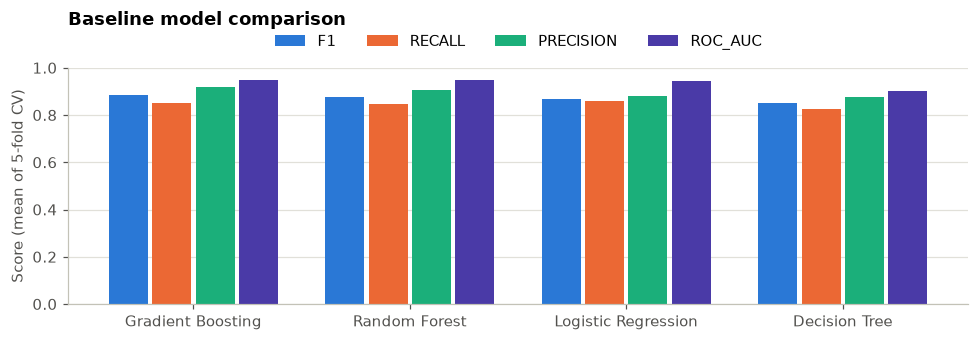

In [26]:
fig, ax = plt.subplots(figsize=(9, 3.2))
metrics_plot = ["f1", "recall", "precision", "roc_auc"]
x = np.arange(len(baseline))
width = 0.2
colors = ["#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"]
for i, (m, c) in enumerate(zip(metrics_plot, colors)):
    ax.bar(x + (i - 1.5) * width, baseline[m], width=width - 0.02, color=c, label=m.upper())
ax.set_xticks(x, baseline.index)
ax.set_ylim(0, 1)
ax.set_ylabel("Score (mean of 5-fold CV)")
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, 1.2))
ax.grid(axis="x", visible=False)
ax.set_title("Baseline model comparison", pad=28)
plt.tight_layout()
plt.show()

**Insight:**
- All four models perform well because the Dropout and Graduate classes are fairly well separated. **Gradient Boosting has the highest F1-score (0.883)**, followed by Random Forest (0.875), Logistic Regression (0.869), and Decision Tree (0.850).
- **Gradient Boosting is chosen** because it:
  1. has the highest F1-score and **the highest precision (0.917)** while keeping a high recall (0.852), making it the best balance between catching at-risk students and avoiding false alarms;
  2. has a ROC-AUC on par with the best model (about 0.95);
  3. can still be explained through *permutation importance* (globally) and a *what-if* analysis per student in the app.
- Logistic Regression has a slightly higher recall (0.858) but a lower precision (0.880). That recall gap can also be closed through threshold selection in the next step.

### 2. Validating the feature selection
To make sure the 20-feature selection does not sacrifice performance, the best model is compared using the **20 selected features** and **all 36 original features**.

In [27]:
best_baseline_name = baseline["f1"].idxmax()
all_nominal = [c for c in nominal_codes]
all_numeric = [c for c in df.columns if c not in all_nominal + ["Status"]]
full_pipe = build_pipeline(candidates[best_baseline_name], numeric=all_numeric,
                           categorical=all_nominal, engineer=True)
X_train_full = model_df.loc[X_train.index].drop(columns="Status")

res_full = cross_validate(full_pipe, X_train_full, y_train, cv=cv, scoring=SCORING)
comparison = pd.DataFrame({
    "36 features (all)": {m: res_full[f"test_{m}"].mean() for m in SCORING},
    "20 features (selected)": baseline.loc[best_baseline_name, SCORING],
}).T
print("Model:", best_baseline_name)
comparison.round(3)

Model: Gradient Boosting


,f1,recall,precision,roc_auc,accuracy
36 features (all),0.883,0.850,0.918,0.950,0.911
20 features (selected),0.883,0.852,0.917,0.949,0.912


**Insight:** With all 36 features the F1-score is exactly the same (**0.883**) and ROC-AUC rises by only about 0.001, so the 16 extra features add no new information. With 20 features the model stays accurate while the data app users have to enter is almost halved. **The feature selection is kept.**

### 3. Hyperparameter tuning
The model with the best baseline F1-score is tuned with `GridSearchCV` (5-fold, F1 metric).

In [28]:
param_grids = {
    "Logistic Regression": {"model__C": [0.01, 0.1, 0.3, 1, 3, 10]},
    "Decision Tree": {"model__max_depth": [4, 6, 8, 10], "model__min_samples_leaf": [1, 10, 30]},
    "Random Forest": {"model__n_estimators": [300, 500], "model__max_depth": [None, 10, 20],
                      "model__min_samples_leaf": [1, 3, 5]},
    "Gradient Boosting": {"model__n_estimators": [100, 200, 300], "model__learning_rate": [0.05, 0.1],
                          "model__max_depth": [2, 3, 4]},
}
grid = GridSearchCV(build_pipeline(candidates[best_baseline_name]), param_grids[best_baseline_name],
                    scoring="f1", cv=cv, n_jobs=-1)
grid.fit(X_train, y_train)
print("Model          :", best_baseline_name)
print("Best params    :", grid.best_params_)
print(f"CV F1 baseline : {baseline.loc[best_baseline_name, 'f1']:.3f}")
print(f"CV F1 tuned    : {grid.best_score_:.3f}")
best_pipeline = grid.best_estimator_

Model          : Gradient Boosting
Best params    : {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}
CV F1 baseline : 0.883
CV F1 tuned    : 0.883


**Insight:** The best combination is `n_estimators=100`, `learning_rate=0.1`, and `max_depth=3`, which is the default setting. More complex combinations (deeper or more trees) do not improve F1, so the simpler model is kept and the risk of overfitting stays lower.

### 4. Choosing the decision threshold
By default the model predicts *Dropout* when the probability is ≥ 0.5. For the institution, however, **missing a student who will actually drop out (false negative) is costlier** than giving guidance to a student who is actually safe (false positive), because one guidance session costs far less than losing a student.

A business rule is therefore set: **the model must catch at least 80% of dropouts (recall ≥ 0.80)**. Among the thresholds that meet this rule, the one with the highest F1-score is chosen to keep false alarms under control. The threshold is chosen using **out-of-fold predictions on the training data**, so the test set stays untouched.

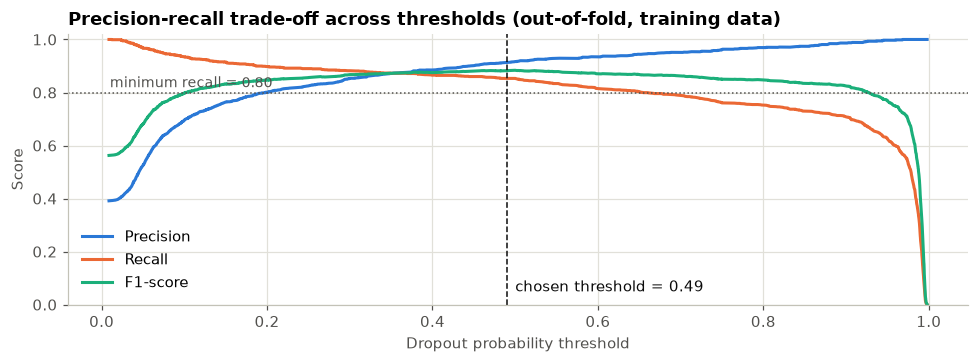

Chosen threshold: 0.49 | precision 0.917 | recall 0.853 | F1 0.884


In [29]:
MIN_RECALL = 0.80
oof_proba = cross_val_predict(best_pipeline, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
precision, recall, thresholds = precision_recall_curve(y_train, oof_proba)
f1_scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
eligible = np.where(recall[:-1] >= MIN_RECALL)[0]
best_idx = int(eligible[np.argmax(f1_scores[eligible])])
THRESHOLD = float(np.floor(thresholds[best_idx] * 100) / 100)

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(thresholds, precision[:-1], color="#2a78d6", lw=2, label="Precision")
ax.plot(thresholds, recall[:-1], color="#eb6834", lw=2, label="Recall")
ax.plot(thresholds, f1_scores, color="#1baf7a", lw=2, label="F1-score")
ax.axhline(MIN_RECALL, color=MUTED, ls=":", lw=1)
ax.text(0.01, MIN_RECALL + 0.02, f"minimum recall = {MIN_RECALL:.2f}", color=MUTED, fontsize=9)
ax.axvline(THRESHOLD, color=INK, ls="--", lw=1)
ax.text(THRESHOLD + 0.01, 0.05, f"chosen threshold = {THRESHOLD:.2f}", color=INK)
ax.set_xlabel("Dropout probability threshold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.02)
ax.legend(loc="lower left")
ax.set_title("Precision-recall trade-off across thresholds (out-of-fold, training data)")
plt.tight_layout()
plt.show()
print(f"Chosen threshold: {THRESHOLD:.2f} | precision {precision[best_idx]:.3f} | "
      f"recall {recall[best_idx]:.3f} | F1 {f1_scores[best_idx]:.3f}")

**Insight:**
- The lower the threshold, the higher the recall (more at-risk students caught), but the lower the precision (more false alarms).
- The threshold with the highest F1 that meets recall ≥ 0.80 is **0.49**. On the training data (out-of-fold) it gives a recall of about 0.85 and a precision of about 0.92, so the business rule is met with a comfortable margin.
- The threshold is saved with the model and used in the app. Besides the Dropout/Graduate label, the app also shows a **risk level** (Low / Medium / High) based on the probability so staff can prioritise interventions.

## Evaluation

### 1. Test set performance
The final model is evaluated **once** on the test set (20% of the Dropout + Graduate data), which was never seen during training, tuning, or threshold selection.

In [30]:
test_proba = best_pipeline.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= THRESHOLD).astype(int)

print(f"Threshold = {THRESHOLD:.2f}\n")
print(classification_report(y_test, test_pred, target_names=["Graduate", "Dropout"], digits=3))
print(f"ROC-AUC: {roc_auc_score(y_test, test_proba):.3f}")

test_metrics = {
    "f1": f1_score(y_test, test_pred),
    "recall": recall_score(y_test, test_pred),
    "precision": precision_score(y_test, test_pred),
    "accuracy": float((test_pred == y_test).mean()),
    "roc_auc": roc_auc_score(y_test, test_proba),
}

Threshold = 0.49

              precision    recall  f1-score   support

    Graduate      0.945     0.932     0.938       442
     Dropout      0.897     0.915     0.906       284

    accuracy                          0.926       726
   macro avg      0.921     0.924     0.922       726
weighted avg      0.926     0.926     0.926       726

ROC-AUC: 0.971


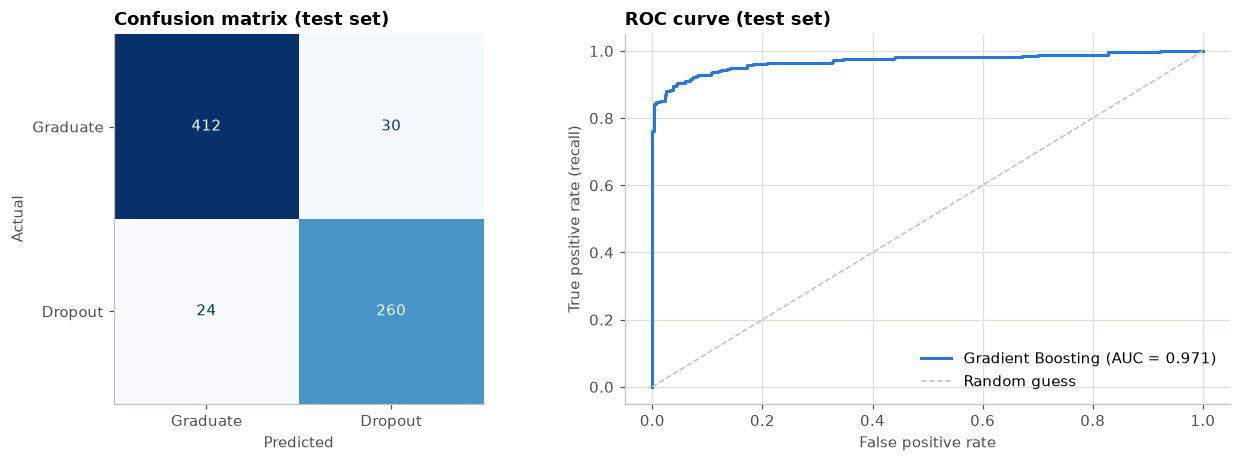

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
ConfusionMatrixDisplay.from_predictions(
    y_test, test_pred, display_labels=["Graduate", "Dropout"], cmap="Blues",
    colorbar=False, ax=axes[0])
axes[0].grid(False)
axes[0].set_title("Confusion matrix (test set)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

fpr, tpr, _ = roc_curve(y_test, test_proba)
axes[1].plot(fpr, tpr, color="#2a78d6", lw=2, label=f"{best_baseline_name} (AUC = {test_metrics['roc_auc']:.3f})")
axes[1].plot([0, 1], [0, 1], color=NEUTRAL, ls="--", lw=1, label="Random guess")
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate (recall)")
axes[1].legend(loc="lower right")
axes[1].set_title("ROC curve (test set)")
plt.tight_layout()
plt.show()

**Insight:**
- On the test set the model achieves **91.5% recall**, **89.7% precision**, an **F1-score of 0.906**, **92.6% accuracy**, and a **ROC-AUC of 0.971**. This is in line with the cross-validation results, so the model **does not overfit**.
- Of the 284 students who actually dropped out, **260 were detected** and only 24 were missed.
- Of the 290 students predicted to drop out, 260 (90%) actually did. In other words, **9 out of 10 students flagged by the model are genuinely at risk**, so little guidance effort is wasted.
- A ROC-AUC of 0.971 shows the model is very good at **ranking** students from most at risk to safest.

### 2. Validating the risk levels
Dropout probabilities are grouped into three risk levels so they are easy to act on. The table below checks the actual dropout rate at each level on the test set.

In [32]:
RISK_LOW_MAX = 0.25
RISK_LABELS = ["Low", "Medium", "High"]


def to_risk_level(proba):
    return pd.cut(proba, bins=[0, RISK_LOW_MAX, THRESHOLD, 1.0001], right=False, labels=RISK_LABELS)


risk_table = (pd.DataFrame({"risk": to_risk_level(test_proba), "actual_dropout": y_test.values})
              .groupby("risk", observed=True)["actual_dropout"]
              .agg(students="size", actual_dropout_rate="mean"))
risk_table["actual_dropout_rate"] = risk_table["actual_dropout_rate"].map("{:.1%}".format)
risk_table

,students,actual_dropout_rate
risk,,
Low,391,3.6%
Medium,45,22.2%
High,290,89.7%


**Insight:** The risk levels are meaningful:
- **Low risk** (probability < 25%): only about 4% actually drop out. Routine monitoring is enough.
- **Medium risk** (25% up to the threshold): about 22% drop out. Academic advisors should monitor them more closely.
- **High risk** (≥ threshold): about 90% drop out. **Top priority for targeted guidance.**

### 3. Most influential factors according to the model
*Permutation importance* measures how much the ROC-AUC drops when a feature's values are shuffled. The bigger the drop, the more the model relies on that feature. It is applied to the 20 raw features so the result is easy to read.

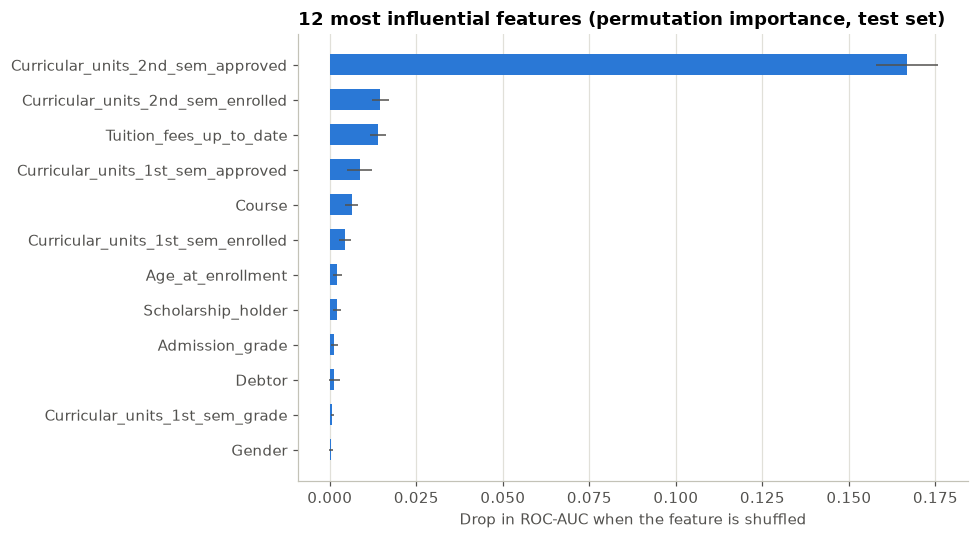

,importance,std
Curricular_units_2nd_sem_approved,0.1667,0.0089
Curricular_units_2nd_sem_enrolled,0.0146,0.0025
Tuition_fees_up_to_date,0.0139,0.0024
Curricular_units_1st_sem_approved,0.0086,0.0036
Course,0.0063,0.0019
Curricular_units_1st_sem_enrolled,0.0044,0.0018
Age_at_enrollment,0.0022,0.0012
Scholarship_holder,0.0021,0.0011
Admission_grade,0.0013,0.0010
Debtor,0.0013,0.0015


In [33]:
perm = permutation_importance(best_pipeline, X_test, y_test, scoring="roc_auc",
                              n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
importance = (pd.DataFrame({"importance": perm.importances_mean, "std": perm.importances_std},
                           index=X_test.columns)
              .sort_values("importance", ascending=True))

top = importance.tail(12)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top.index, top["importance"], xerr=top["std"], color="#2a78d6", height=0.6,
        error_kw={"ecolor": MUTED, "lw": 1})
ax.set_xlabel("Drop in ROC-AUC when the feature is shuffled")
ax.grid(axis="y", visible=False)
ax.set_title("12 most influential features (permutation importance, test set)")
plt.tight_layout()
plt.show()
importance.sort_values("importance", ascending=False).round(4).head(12)

**Insight:**
- **The number of courses passed in semester 2** is by far the most dominant feature. It is followed by **courses enrolled in semester 2**, **tuition payment status**, and **courses passed in semester 1**.
- The next factors are **study program, courses enrolled in semester 1, age at enrollment, and scholarship status**.
- This is **consistent with the EDA**: early academic signals and financial condition are the main indicators of dropout, and both are factors the institution **can monitor and act on**.

### 4. Saving the model
The model is saved as one complete pipeline (feature engineering + preprocessing + model) with `joblib`. The metadata (features, threshold, metrics, and data sizes) is saved separately as JSON for the Streamlit app.

In [34]:
joblib.dump(best_pipeline, "model/dropout_model.joblib")

metadata = {
    "model_name": best_baseline_name,
    "best_params": {k.replace("model__", ""): v for k, v in grid.best_params_.items()},
    "target": "Dropout (1) vs Graduate (0); Enrolled students are not used for training",
    "n_model_rows": int(len(model_df)),
    "n_train": int(len(X_train)),
    "n_test": int(len(X_test)),
    "n_enrolled": int(len(enrolled_df)),
    "threshold": THRESHOLD,
    "risk_low_max": RISK_LOW_MAX,
    "features": MODEL_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "numeric_features": NUMERIC_FEATURES,
    "test_metrics": {k: round(float(v), 4) for k, v in test_metrics.items()},
    "feature_importance": importance["importance"].sort_values(ascending=False).round(4).to_dict(),
    "sklearn_version": sklearn.__version__,
}
with open("model/model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)
print(json.dumps({k: v for k, v in metadata.items() if k != "feature_importance"}, indent=2))

{
  "model_name": "Gradient Boosting",
  "best_params": {
    "learning_rate": 0.1,
    "max_depth": 3,
    "n_estimators": 100
  },
  "target": "Dropout (1) vs Graduate (0); Enrolled students are not used for training",
  "n_model_rows": 3630,
  "n_train": 2904,
  "n_test": 726,
  "n_enrolled": 794,
  "threshold": 0.49,
  "risk_low_max": 0.25,
  "features": [
    "Marital_status",
    "Application_mode",
    "Course",
    "Daytime_evening_attendance",
    "Admission_grade",
    "Previous_qualification_grade",
    "Displaced",
    "Debtor",
    "Tuition_fees_up_to_date",
    "Gender",
    "Scholarship_holder",
    "Age_at_enrollment",
    "Curricular_units_1st_sem_enrolled",
    "Curricular_units_1st_sem_evaluations",
    "Curricular_units_1st_sem_approved",
    "Curricular_units_1st_sem_grade",
    "Curricular_units_2nd_sem_enrolled",
    "Curricular_units_2nd_sem_evaluations",
    "Curricular_units_2nd_sem_approved",
    "Curricular_units_2nd_sem_grade"
  ],
  "categorical_features":

### 5. Predicting Enrolled students (future data)
The final model is used to predict the **794 Enrolled students** that were set aside at the start. These students do not have a final outcome yet, so these are the predictions the institution can act on right away. The results are saved to `data/enrolled_predictions.csv`, and 25 of them become the sample input for the app's batch prediction feature (`data/sample_batch_input.csv`).

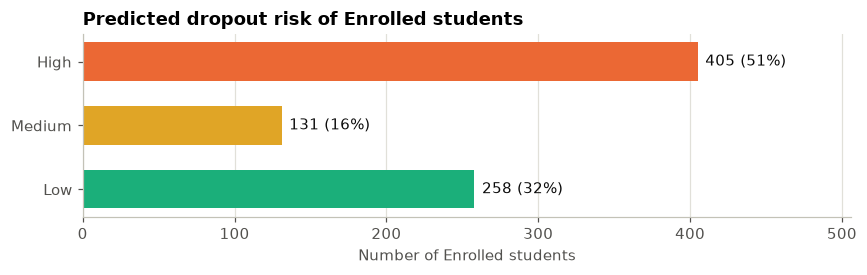

,Student_id,Study_program,Age_at_enrollment,Courses_passed_sem_2,Tuition_paid_up,Dropout_probability,Risk_level,Prediction
264,1558,Management,18,0,1,0.9988,High,Dropout
390,2240,Veterinary Nursing,25,0,0,0.9960,High,Dropout
553,3078,Informatics Engineering,27,0,0,0.9954,High,Dropout
156,855,Informatics Engineering,18,0,0,0.9951,High,Dropout
29,143,Management,22,0,0,0.9947,High,Dropout
162,929,Veterinary Nursing,28,0,1,0.9946,High,Dropout
481,2679,Agronomy,26,0,1,0.9942,High,Dropout
134,764,Management,40,1,1,0.9941,High,Dropout
19,90,Informatics Engineering,18,0,1,0.9940,High,Dropout
207,1249,Advertising and Marketing Management,21,1,1,0.9935,High,Dropout


In [35]:
loaded = joblib.load("model/dropout_model.joblib")
enrolled_proba = loaded.predict_proba(X_enrolled)[:, 1]

enrolled_pred = pd.DataFrame({
    "Student_id": enrolled_df.index + 1,  # same as Student_id in the dashboard data
    "Study_program": enrolled_df["Course"].map(COURSE).values,
    "Age_at_enrollment": enrolled_df["Age_at_enrollment"].values,
    "Courses_passed_sem_2": enrolled_df["Curricular_units_2nd_sem_approved"].values,
    "Tuition_paid_up": enrolled_df["Tuition_fees_up_to_date"].values,
    "Dropout_probability": enrolled_proba.round(4),
    "Risk_level": to_risk_level(enrolled_proba).astype(str),
    "Prediction": np.where(enrolled_proba >= THRESHOLD, "Dropout", "Graduate"),
}).sort_values("Dropout_probability", ascending=False)
enrolled_pred.to_csv("data/enrolled_predictions.csv", index=False)

# Sample input file for the app's batch prediction feature: 25 Enrolled students
sample = X_enrolled.sample(25, random_state=RANDOM_STATE).copy()
sample.insert(0, "Student_id", [f"STD-{i + 1:04d}" for i in sample.index])
sample.to_csv("data/sample_batch_input.csv", index=False)

risk_counts = enrolled_pred["Risk_level"].value_counts().reindex(RISK_LABELS)
fig, ax = plt.subplots(figsize=(8, 2.6))
risk_colors = {"Low": "#1baf7a", "Medium": "#e0a526", "High": HIGHLIGHT}
bars = ax.barh(risk_counts.index, risk_counts.values, color=[risk_colors[r] for r in risk_counts.index], height=0.6)
for b, v in zip(bars, risk_counts.values):
    ax.text(b.get_width() + 5, b.get_y() + b.get_height() / 2,
            f"{v:,} ({v / len(enrolled_pred):.0%})", va="center", color=INK)
ax.set_xlim(0, risk_counts.max() * 1.25)
ax.set_xlabel("Number of Enrolled students")
ax.grid(axis="y", visible=False)
ax.set_title("Predicted dropout risk of Enrolled students")
plt.tight_layout()
plt.show()
enrolled_pred.head(10)

In [36]:
enrolled_pred.groupby("Risk_level")[["Age_at_enrollment", "Courses_passed_sem_2", "Tuition_paid_up"]].mean().reindex(RISK_LABELS).round(2)

,Age_at_enrollment,Courses_passed_sem_2,Tuition_paid_up
Risk_level,,,
Low,22.57,5.74,1.00
Medium,22.53,4.34,0.95
High,22.19,2.89,0.92


**Insight:**
- Of the 794 Enrolled students, **405 (51%) are predicted to be at High risk**, 131 (16%) at Medium risk, and 258 (32%) at Low risk.
- High-risk Enrolled students passed only **2.9 courses in semester 2** on average (vs 5.7 in the Low-risk group), and 8% of them are behind on tuition (vs 0% in the Low-risk group). This pattern matches the main dropout drivers found in the EDA.
- Enrolled students have already passed the normal study period, so this High-risk group is the **most urgent priority for intervention**: they can still be helped, but they are very likely to quit.
- The full list with probabilities is in `data/enrolled_predictions.csv` and can be used directly by academic advisors.

## Conclusion

**Answering the business problems:**

1. **How high is the dropout rate?** **32.1% of students (1,421 of 4,424) dropped out**, roughly 1 in 3.

2. **Which factors are most associated with dropout?**
   - **Academic (strongest):** few courses passed and low grades in semesters 1–2. Students who passed no courses in semester 2 have a dropout rate of 84%.
   - **Financial:** overdue tuition (87% dropout), debt (62%), and no scholarship (39% vs 12% for scholarship holders).
   - **Demographic:** enrollment age ≥25 (>50% dropout), male (45% vs 25%), married, and evening classes.
   - **Admission path & program:** the *Over 23 years old* (55%) and *Holders of other higher courses* (61%) paths, and the Equinculture, Informatics Engineering, and Management (evening) programs with dropout rates above 50%.
   - Parents' education and macroeconomic conditions have **no** meaningful effect.

3. **How can at-risk students be detected early?** A **Gradient Boosting** model is trained on 3,630 Dropout and Graduate students (target 1 = Dropout, 0 = Graduate) with 20 features. On the test set it detects **91.5% of students who will drop out** with 89.7% precision (F1 0.906; ROC-AUC 0.971). The model comes with **Low / Medium / High** risk levels, is used to predict the 794 Enrolled students (405 at High risk), and is deployed as a Streamlit application prototype.

4. **How can student performance be monitored?** The cleaned data (`data/students_clean.csv`, `data/students.db`) feeds a Metabase dashboard that tracks the factors above for all students.